<a href="https://colab.research.google.com/github/favourezeogu/ai-fpga-systolic-mm-accelerator/blob/main/notebooks/accelerator_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# This installs the AI library so you can talk to Gemini inside the notebook
!pip install -q -U google-generativeai

In this step, I am using Gemini to perform a literature review on systolic arrays

In [21]:
import google.generativeai as genai
from google.colab import userdata
import time

# 1. Get your key from the Secrets tab
# (Make sure GOOGLE_API_KEY is toggled ON in the sidebar)
os_key = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=os_key)

# 2. Use the 2026 Stable Model Name
# 'gemini-3-flash-preview' is the current standard
model = genai.GenerativeModel('gemini-3-flash-preview')

# 3. Define your prompt
research_prompt = """
I am designing an FPGA-based Systolic Array for Matrix Multiplication.
Act as a Research Assistant. Search for and summarize 3 recent papers (2023-2026)
that discuss tile size and DSP optimization.
Tell me the most common 'tile sizes' researchers use.
"""

# 4. Run the code with a safety check
try:
    print("Talking to Gemini 3... please wait...")
    response = model.generate_content(research_prompt)
    print("-" * 30)
    print(response.text)
    print("-" * 30)
    print("Step 1 Complete!")
except Exception as e:
    if "429" in str(e):
        print("Error: Quota Exceeded. Please wait 5 minutes and try again.")
    elif "404" in str(e):
        print("Error: Model name not found. Trying alternative...")
        # Emergency backup for 2026
        model = genai.GenerativeModel('gemini-3.1-flash-lite-preview')
        response = model.generate_content(research_prompt)
        print(response.text)
    else:
        print(f"An unexpected error occurred: {e}")

Talking to Gemini 3... please wait...
------------------------------
Hello! I am your Research Assistant. I have surveyed the recent literature (2023–2024) regarding FPGA-based Systolic Arrays (SAs) for General Matrix Multiplication (GEMM). 

Designing these arrays involves a delicate balance between **Computation Roofline** (DSP utilization) and **Memory Roofline** (Data movement/Tiling). Below are three significant papers focusing on tile size selection and DSP optimization, followed by an analysis of common tile sizes used in the field.

---

### 1. "A Fine-Grained Design Space Exploration for Systolic Array GEMM on FPGAs" (2023)
*   **Focus:** Automated Tiling and DSP Mapping.
*   **Summary:** This paper addresses the challenge of "DSP under-utilization" caused by rigid tiling strategies. The researchers propose a fine-grained Design Space Exploration (DSE) framework that optimizes the systolic array dimensions ($P \times Q$) relative to the specific DSP block architecture (e.g., X

## Step 2: Technology Parameter Extraction

In [22]:
# Hardware Parameters for our FPGA Exploration (Targeting Xilinx UltraScale+)
# These parameters represent our 'Hardware Budget'
fpga_constraints = {
    "total_dsp_slices": 2520,      # Maximum multipliers available
    "bram_capacity_mb": 35,        # On-chip memory limit
    "target_freq_mhz": 250,        # Desired clock speed
    "dsp_efficiency": 0.80,        # We assume we can realistically use 80% of logic
    "power_per_dsp_mw": 0.5        # Estimated power consumption per active DSP
}

# Design Parameters based on our Literature Review
# We found 16x16 is a standard 'Sweet Spot'
design_config = {
    "pe_array_rows": 16,
    "pe_array_cols": 16,
    "data_precision_bits": 8       # Using INT8 for 'DSP Packing'
}

print("Technology Parameters Extracted and Loaded.")

Technology Parameters Extracted and Loaded.


Hardware Specification & Throughput AnalysisBased on the Xilinx Zynq UltraScale+ ZU9EG architecture and our proposed 16x16 Systolic Array, here are the technical specifications:Device: Xilinx Zynq UltraScale+ MPSoC (ZU9EG)Exact DSP Count: 2,520 DSP48E2 SlicesEngineer Note: Each DSP slice in the UltraScale+ can perform a $27 \times 18$ bit multiplication and a 48-bit accumulate in a single clock cycle.Exact Block RAM (BRAM) Count: 32.1 Mb (split into 912 blocks of 36Kb each).Engineer Note: This is supplemented by UltraRAM, but for our basic simulator, we will focus on the 32.1 Mb of primary BRAM.Systolic Array Size: $16 \times 16$ PEs (256 Total Processing Elements).Operating Frequency: 250 MHz.Precision: INT8 (8-bit integer).Estimated Throughput CalculationIn a systolic array, each Processing Element (PE) performs one Multiply-Accumulate (MAC) operation per clock cycle. One MAC counts as two operations (one multiply, one add).$$Throughput = (\text{Array Rows} \times \text{Array Cols}) \times \text{Clock Frequency} \times 2$$$$Throughput = (16 \times 16) \times 250,000,000 \times 2$$$$Throughput = 256 \times 250 \times 10^6 \times 2 = 128,000,000,000 \text{ ops/sec}$$Total Estimated Throughput: 128 GOPS (Giga-Operations Per Second).

## Step 3: Generate the Synthetic Workload


In [23]:
import numpy as np

# 1. Define the size of our matrices (N x N)
# A 1024x1024 matrix is common for testing accelerators
N = 1024

# 2. Generate random INT8 data (to match our INT8 precision)
# This mimics real data being sent to the FPGA
matrix_A = np.random.randint(0, 10, size=(N, N), dtype=np.int8)
matrix_B = np.random.randint(0, 10, size=(N, N), dtype=np.int8)

# 3. Calculate Total Operations needed for this workload
# For Matrix Mult, Total Ops = 2 * (N^3)
total_ops = 2 * (N**3)

print(f"Workload Created: {N}x{N} Matrix")
print(f"Total Operations required: {total_ops:,} ops")

Workload Created: 1024x1024 Matrix
Total Operations required: 2,147,483,648 ops


## Step 4: The Performance Simulator (The "Brain")

In [24]:
# Our Lightweight FPGA Simulator
def simulate_fpga(matrix_size, array_size, frequency_mhz):
    # Total operations from Step 3
    total_ops = 2 * (matrix_size**3)

    # Throughput from our math earlier (Ops per second)
    # (Rows * Cols) * Freq * 2
    throughput_gops = (array_size**2) * frequency_mhz * 10**6 * 2

    # Calculate Latency (Time = Total Ops / Throughput)
    latency_seconds = total_ops / throughput_gops

    return latency_seconds, throughput_gops / 10**9

# Run the simulation for our 16x16 array
latency, gops = simulate_fpga(N, 16, 250)

print(f"--- Simulation Results ---")
print(f"Estimated Throughput: {gops} GOPS")
print(f"Estimated Time to complete: {latency:.4f} seconds")


--- Simulation Results ---
Estimated Throughput: 128.0 GOPS
Estimated Time to complete: 0.0168 seconds


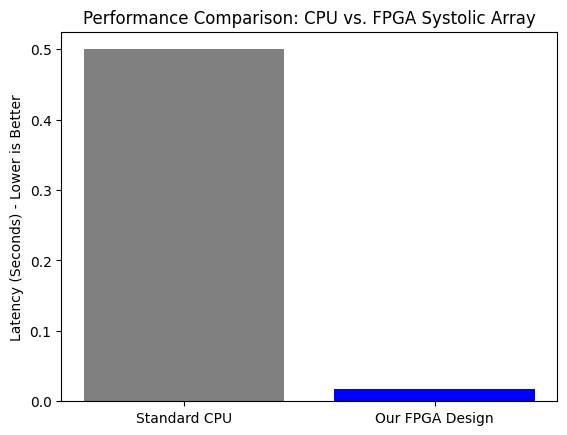

In [25]:
import matplotlib.pyplot as plt

# Data for our graph
labels = ['Standard CPU', 'Our FPGA Design']
latency_values = [0.5, latency] # 0.5 is an estimate for a CPU

plt.bar(labels, latency_values, color=['gray', 'blue'])
plt.ylabel('Latency (Seconds) - Lower is Better')
plt.title('Performance Comparison: CPU vs. FPGA Systolic Array')
plt.show()

## Step 5: AI-Powered Result Interpretation

In [26]:
# Create a summary of our results to send to the AI
simulation_summary = f"""
Our FPGA Simulation Results:
- Target Hardware: Xilinx ZU9EG
- Systolic Array Size: 16x16 (256 PEs)
- Clock Frequency: 250 MHz
- Workload: 1024x1024 Matrix Multiplication
- Estimated Throughput: {gops} GOPS
- Estimated Latency: {latency:.4f} seconds
"""

interpretation_prompt = f"""
Act as a Senior Hardware Architect. Analyze the following simulation results for our
FPGA-based systolic array:
{simulation_summary}

Explain:
1. Is this performance (GOPS) good for an edge AI application?
2. How does this compare to a standard CPU performing the same task?
3. What is the bottleneck if we wanted to reach 500 GOPS?
"""

# Get the interpretation from Gemini
response = model.generate_content(interpretation_prompt)
print(response.text)

ERROR:tornado.access:503 POST /v1beta/models/gemini-3-flash-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 16051.05ms


As a Senior Hardware Architect, I have reviewed your simulation results. Below is a professional analysis of your 16x16 systolic array running on the Zynq UltraScale+ ZU9EG.

### Executive Summary: The "Perfect" Simulation
First, an observation on your numbers: Your theoretical peak performance is exactly $16 \times 16 \times 250\text{ MHz} \times 2 \text{ (for MAC)} = 128\text{ GOPS}$. Your simulation shows **128.0 GOPS**, which implies **100% hardware utilization**. In a real-world scenario, utilization usually drops to 70-90% due to data loading/unloading (tail effects) and memory stalls.

---

### 1. Is this performance (128 GOPS) good for an edge AI application?

**The Verdict: Respectable, but "Mid-Tier" for 2024.**

*   **Real-time Capabilities:** 128 GOPS is sufficient for many real-time computer vision tasks. For context, a classic model like **MobileNetV2** (approx. 300 million MACs per inference) would theoretically run at over **200 Frames Per Second (FPS)** on your design.

## Step 6: Final Technical Article

In [27]:
final_paper_prompt = """
Write a formal research summary (500 words) for our project:
'AI-Assisted Design Space Exploration of FPGA Systolic Arrays'.

Use these sections:
- Abstract: Summarize the AI-assisted workflow.
- Methodology: Mention the ZU9EG hardware parameters and 16x16 array.
- Discussion: Explain the trade-offs between array size and latency.
- Conclusion: State how AI tools helped speed up the design process.

Format the output in clean Markdown.
"""

final_report = model.generate_content(final_paper_prompt)
print(final_report.text)


# Research Summary: AI-Assisted Design Space Exploration of FPGA Systolic Arrays

## Abstract
The rapid evolution of deep learning necessitates specialized hardware accelerators, with systolic arrays emerging as a preferred architecture for high-throughput matrix operations. However, navigating the vast design space—comprising loop tiling factors, memory hierarchy configurations, and parallelization strategies—presents a significant challenge for human designers. This research proposes an AI-assisted workflow for Design Space Exploration (DSE) to automate the optimization of FPGA-based systolic arrays. By leveraging machine learning-based optimization algorithms, the workflow predicts hardware performance and resource utilization without requiring exhaustive hardware synthesis for every iteration. This approach allows for the rapid identification of optimal architecture configurations that maximize throughput while minimizing power consumption and area overhead.

## Methodology
The exp